In [1]:
import os
os.environ.setdefault("MPLBACKEND", "Agg")                     
os.environ.setdefault("JAX_PLATFORM_NAME", "gpu")               # prefer GPU if available
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false") # avoids long initial GPU prealloc
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", "0.85") # cap JAX memory use (optional)

'0.85'

In [7]:
import sys
import numpy as np
import pandas as pd
from numpyro.infer import Predictive
import jax
import jax.numpy as jnp
import tqdm as notebook_tqdm
import matplotlib.pyplot as plt

In [3]:
%load_ext autoreload
%autoreload 2

In [8]:
#custom packages
sys.path.append("/home/nokada/projects/LIMA_Analysis_clean/Code/Modeling/behavior_2/models")

from parallel_fitting import fit_models_parallel, load_fitted_models,   posterior_trial_predictions_df, compute_calibration_metrics
from model_comparison import compare_models, export_comparison_table, print_parameter_summary, clear_gpu_memory
from base import FETExponential, FETLinear, FETQuadratic, FETHyperbolic, ThreatOnly, EffortOnly, FETExponentialVigor, FETExponentialGamma, FETGammaLinearZPower, FETThreatScaled, FETDangerBias
from posterior_predictive import PosteriorPredictive
import pickle

sys.path.append("/home/nokada/projects/LIMA_Analysis_clean/Code/Modeling/behavior_2/plotter")
import plotter

In [9]:
#@TODO need to move this to the preprocessing pipeline
df =pd.read_csv('/home/nokada/projects/LIMA_analysis/Code/Data/behavior_270.csv')

def calculate_distance_H(row):
    if row['effort_H'] == 0.6:
        return 1
    elif row['effort_H'] == 0.8:
        return 2
    elif row['effort_H'] == 1.0:
        return 3
    else:
        return np.nan
    
df['distance_H'] = df.apply(calculate_distance_H, axis=1)
df['distance_L'] = 1

In [ ]:
from parameter_recovery_additive import run_parameter

# Test parameter recovery
recovery_df, fig = run_parameter(
    model_class=FETGammaLinearZPower,
    n_subjects=50,
    n_trials_per_subject=200,
    fixed_tau=1.0
)
plt.show()

# # Fit to real data
# model = FETGammaZAdditive()
# model.fit(data=data)


PARAMETER RECOVERY: FETThreatScaled
Model: S = exp(-threat × (danger^z + γ))
  γ: baseline threat reactivity (LEVEL)
  z: danger curvature (GAP between options)

Simulating 50 subjects × 200 trials

Total trials: 10000
True parameter ranges:
  γ_true: [0.210, 1.945]
  z_true: [0.570, 1.980]
  τ_true: 1.000 (global)

Fitting model...
Fitting FETThreatScaled:
  50 subjects
  10000 total trials
  Effort component: False
  Threat component: True


sample: 100%|██████████| 1000/1000 [00:34<00:00, 28.66it/s]


✓ Fitting complete

RECOVERY RESULTS
  γ (baseline threat reactivity): r = 0.888, p = 0.0000
  z (danger curvature):           r = 0.963, p = 0.0000

Identifiability check:
  Corr(γ_true, z_true):           r = -0.084 (should be ~0)
  Corr(γ_recovered, z_recovered): r = -0.183
  ✓ Excellent! Parameters are well-separated

Bias check:
  γ: true=0.993, recovered=0.876, bias=-0.117
  z: true=1.249, recovered=1.251, bias=+0.001

SUMMARY
  ✓✓ EXCELLENT: Both parameters recover well and are independent!


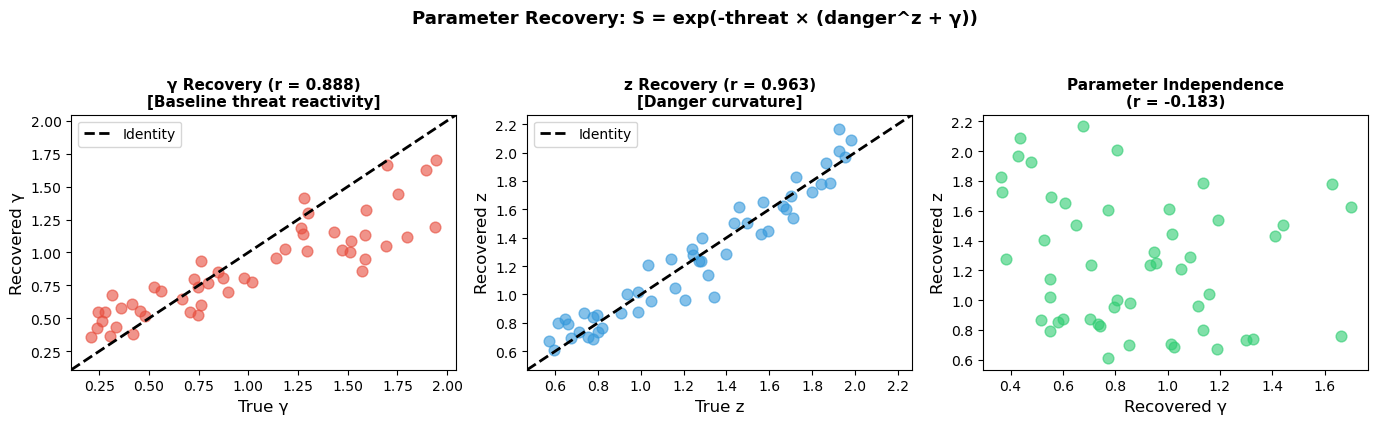

In [6]:
from parameter_recovery_threat_scaled import run_parameter_recovery_threat_scaled


recovery_df, fig = run_parameter_recovery_threat_scaled(
    model_class=FETThreatScaled,
    n_subjects=50,
    n_trials_per_subject=200,
    fixed_tau=1.0
)
plt.show()

PARAMETER RECOVERY: FETDangerBias
Model: S = exp(-threat × danger^z)
       logit(P) = (SV_H - SV_L)/τ - β × threat

  z: danger curvature (value computation)
  β: threat-induced bias (choice intercept)

Simulating 50 subjects × 200 trials

Total trials: 10000
True parameter ranges:
  z_true: [0.508, 1.954]
  β_true: [0.093, 1.974]
  τ_true: 1.000 (global)

Fitting model...
Fitting FETDangerBias:
  50 subjects
  10000 total trials
  Effort component: False
  Threat component: True


sample: 100%|██████████| 1000/1000 [00:46<00:00, 21.52it/s]


✓ Fitting complete

RECOVERY RESULTS
  z (danger curvature):      r = 0.975, p = 0.0000
  β (threat-induced bias):   r = 0.764, p = 0.0000

Identifiability check:
  Corr(z_true, β_true):           r = -0.084 (should be ~0)
  Corr(z_recovered, β_recovered): r = 0.162
  ✓ Excellent! Parameters are well-separated

Bias check:
  z: true=1.161, recovered=1.156, bias=-0.005
  β: true=0.999, recovered=0.930, bias=-0.069

SUMMARY
  ✓ GOOD: Acceptable recovery for both parameters


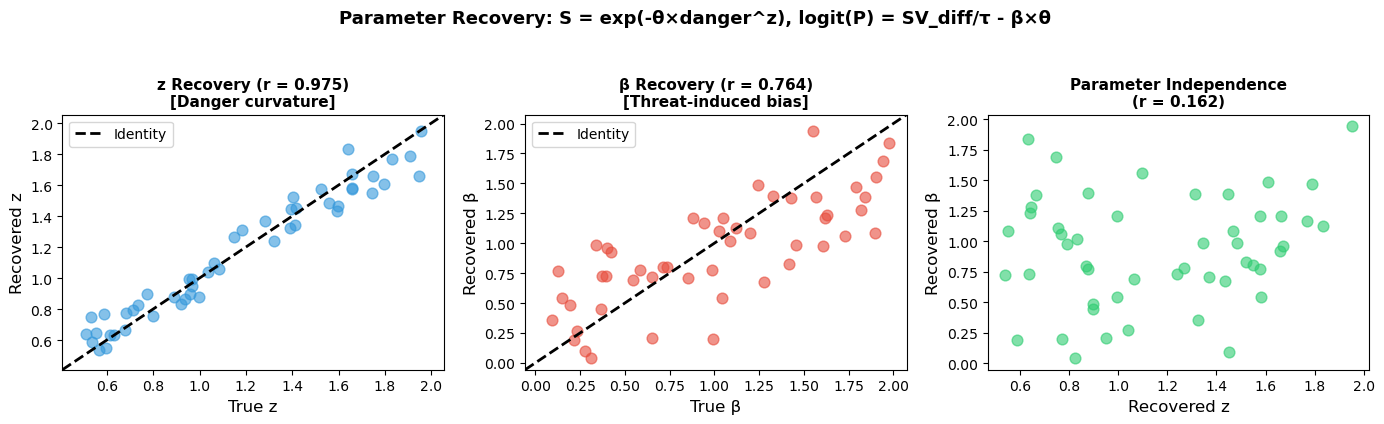

In [10]:
from parameter_recovery_danger_bias import run_parameter_recovery_danger_bias

recovery_df, fig = run_parameter_recovery_danger_bias(
    model_class=FETDangerBias,
    n_subjects=50,
    n_trials_per_subject=200,
    fixed_tau=1.0
)
plt.show()
